In [12]:
from minisom import MiniSom

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler

import math
import numpy as np

import matplotlib.pyplot as plt

In [13]:
iris = load_iris()
features = iris.data
labels = iris.target
type(iris)
# print(f'{features[0]} ')


sklearn.utils._bunch.Bunch

In [14]:
sc = MinMaxScaler(feature_range = (0,1))
features = sc.fit_transform(features)

In [15]:
sigma = 1.5
lr = 0.5
n_features = features.shape[1]
n_samples = features.shape[0]
print(f"number of samples: {n_samples}")

map_size = 5 * math.sqrt(n_samples)
map_height = map_width = math.ceil(math.sqrt(map_size))


print(f'(map_height, map_width) = ({map_height}, {map_width})')
print(f'Number of features: {n_features}')

number of samples: 150
(map_height, map_width) = (8, 8)
Number of features: 4


In [16]:
som = MiniSom(x=map_height, y=map_width, input_len=n_features, sigma=sigma, learning_rate=lr, 
              neighborhood_function='gaussian', random_seed=123)
 
som.pca_weights_init(features)
som.train(data=features, num_iteration=1000, verbose=True)  # random training

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.06946712589245212


c:\Users\abdul\anaconda3\Lib\site-packages\minisom.py:447: ComplexWarning: Casting complex values to real discards the imaginary part
  self._weights[i, j] = c1*pc[pc_order[0]] + \


In [17]:
# print('-------------\nDistance Map\n------------')
print(f'Shape: {som.distance_map().shape}')
# print(f'First Line: {som.distance_map().T}')

Shape: (8, 8)


In [18]:
# frequencies = som.activation_response(features)
# print(f'Frequencies:\n {np.array(frequencies, np.uint)}')
# print(frequencies)

In [19]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


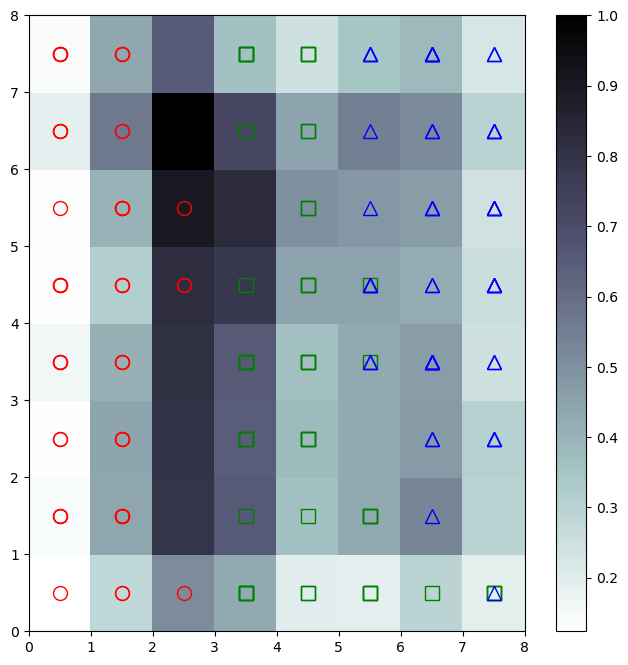

In [20]:
plt.figure(figsize=(map_height, map_width))

# plot U-matrix
u_matrix = som.distance_map().T
plt.pcolor(u_matrix, cmap='bone_r')
plt.colorbar()

# plot markers
markers = ['o', 's', '^']   # 'setosa', 'versicolor' 'virginica'
colors = ['r', 'g', 'b']
w0=[] 
w1=[]
lbl=[]
mkrs=[]

for feature, label in zip(features, labels):
    w = som.winner(feature)
    w0=np.concatenate((w0, w[0]), axis=None)
    w1=np.concatenate((w1, w[1]), axis=None)
    lbl=np.concatenate((lbl, label), axis=None)
    mkrs=np.concatenate((mkrs,iris.target_names[label]), axis=None)

    plt.plot(w[0] + 0.5, w[1] + 0.5, 
        markers[label], markeredgecolor = colors[label], 
        markerfacecolor = 'None', markersize = 10, markeredgewidth = 1)

plt.show()